# MapleFreight Delivery Delay Prediction & Slack Alerts
**Author:** Anush Adhikari | **ID:** C0968893

## 1. Problem and Objective
MapleFreight's on-time rate fell from 94% to 88%, and delays are only found after the customer calls. This notebook builds a model that predicts which in-transit shipments will be late and sends a Slack alert to dispatch while there is still time to act.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid") # RANDOM_STATE constant makes results repeatable, so every later model uses the same seed.
RANDOM_STATE = 42

# Load data
df = pd.read_csv("maplefreight_delivery_delay_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (6035, 23)


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


## 2. Data Understanding
Checking size, types, missing values, duplicates, spellings and units.

## structure and missing values

In [2]:
# Types and missing values
df.info()
df.isna().sum()[df.isna().sum() > 0]

<class 'pandas.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                6035 non-null   str    
 1   origin_city                6035 non-null   str    
 2   destination_city           6035 non-null   str    
 3   carrier                    6035 non-null   str    
 4   service_level              6035 non-null   str    
 5   goods_type                 6035 non-null   str    
 6   customer_priority_tier     6035 non-null   str    
 7   shipment_month             6035 non-null   int64  
 8   distance_km                6035 non-null   float64
 9   weight_kg                  6035 non-null   float64
 10  num_stops                  6035 non-null   int64  
 11  is_cross_border            6035 non-null   int64  
 12  scheduled_transit_hours    6035 non-null   float64
 13  pickup_delay_minutes       6035 non-null   float64
 14  dri

driver_experience_years    210
weather_condition          150
traffic_index              121
fuel_cost_cad              240
dtype: int64

## duplicates

In [3]:
# Duplicate rows and repeated shipment IDs
print("Identical rows:", df.duplicated().sum())
print("Repeated shipment_id:", df["shipment_id"].duplicated().sum())

Identical rows: 32
Repeated shipment_id: 35


## spellings and target balance

In [4]:
# Inconsistent spellings and class balance
print(df["service_level"].value_counts())
print(df["delivered_late"].value_counts(normalize=True).round(3))

service_level
Standard    3219
Express     1442
Economy     1254
standard      74
express       27
economy       19
Name: count, dtype: int64
delivered_late
0    0.794
1    0.206
Name: proportion, dtype: float64


## unit check on weight

In [5]:
# Weight outliers (possible grams entered as kg)
print((df["weight_kg"] > 10000).sum(), "rows above 10,000 kg")
df["weight_kg"].describe()

40 rows above 10,000 kg


count    6.035000e+03
mean     6.928251e+03
std      8.375515e+04
min      3.000000e+01
25%      4.960000e+02
50%      8.271000e+02
75%      1.286300e+03
max      2.999300e+06
Name: weight_kg, dtype: float64

**Findings**
- 6,035 rows, 23 columns; about 20.6% of shipments are late.
- Missing values in driver_experience_years (210), weather_condition (150), traffic_index (121) and fuel_cost_cad (240).
- 32 identical rows and 35 repeated shipment IDs.
- `service_level` has 6 data (capital and normal words) instead of 3. `(Standard, standard, Express, express, Economy, economy)`
- 40 weights are above 10,000 kg, likely grams entered as kg.
- `actual_transit_hours` is only known after delivery, so it will be dropped to avoid leakage.

# 3. Data Cleaning
Fixing spellings and units, removing duplicates and dropping the leakage column. Missing values are filled after the train/test split.

## spellings

In [6]:
# Standardise service_level to Express / Standard / Economy
df["service_level"] = df["service_level"].str.strip().str.title()
print(df["service_level"].value_counts())

service_level
Standard    3293
Express     1469
Economy     1273
Name: count, dtype: int64


## duplicates

In [7]:
# Drop duplicates (identical rows, then repeated IDs)
before = len(df)
df = df.drop_duplicates().drop_duplicates(subset="shipment_id").reset_index(drop=True)
print("Rows removed:", before - len(df), "| Rows left:", len(df))

Rows removed: 35 | Rows left: 6000


## weight units


In [8]:
# Weights above 10,000 are grams entered as kg, so divide by 1000
bad = df["weight_kg"] > 10000
print("Fixed rows:", bad.sum())
df.loc[bad, "weight_kg"] = df.loc[bad, "weight_kg"] / 1000
df["weight_kg"].describe()

Fixed rows: 40


count    6000.000000
mean      953.857233
std       618.390918
min        30.000000
25%       494.650000
50%       823.450000
75%      1274.425000
max      5044.000000
Name: weight_kg, dtype: float64

## drop leakage cloumns


In [9]:
# Remove the column that is only known after delivery
df = df.drop(columns=["actual_transit_hours"])
print("Columns left:", df.shape[1])

Columns left: 22


**Findings**
- service_level now has 3 clean categories.
- 35 duplicate rows removed , leaving 6,000 shipments.
- 40 weights were in grams and were converted to kg; the maximum is now about 3,000 kg.
- `actual_transit_hours` dropped to prevent data leakage.
- Missing values will be filled after the split.

# **4. Exploratory Data Analysis (EDA)**
Which factors are linked to late delivery?

## target balance

delivered_late
0    0.794
1    0.206
Name: proportion, dtype: float64


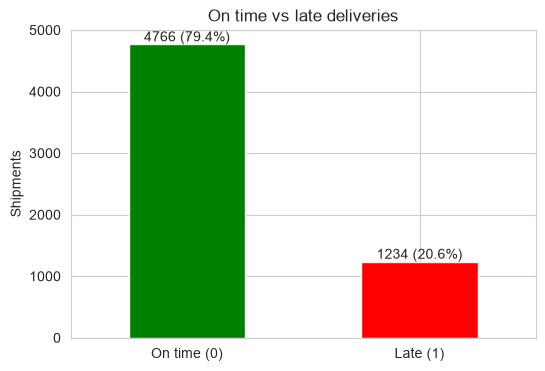

In [13]:
# Class balance
counts = df["delivered_late"].value_counts().sort_index()
print(df["delivered_late"].value_counts(normalize=True).round(3))

ax = counts.plot(kind="bar", color=["green", "red"], figsize=(6, 4))
ax.set_title("On time vs late deliveries")
ax.set_xticklabels(["On time (0)", "Late (1)"], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("Shipments")

# Count and % on each bar
for i, v in enumerate(counts):
    ax.text(i, v + 50, f"{v} ({v/len(df):.1%})", ha="center")
plt.show()

## late rate by category

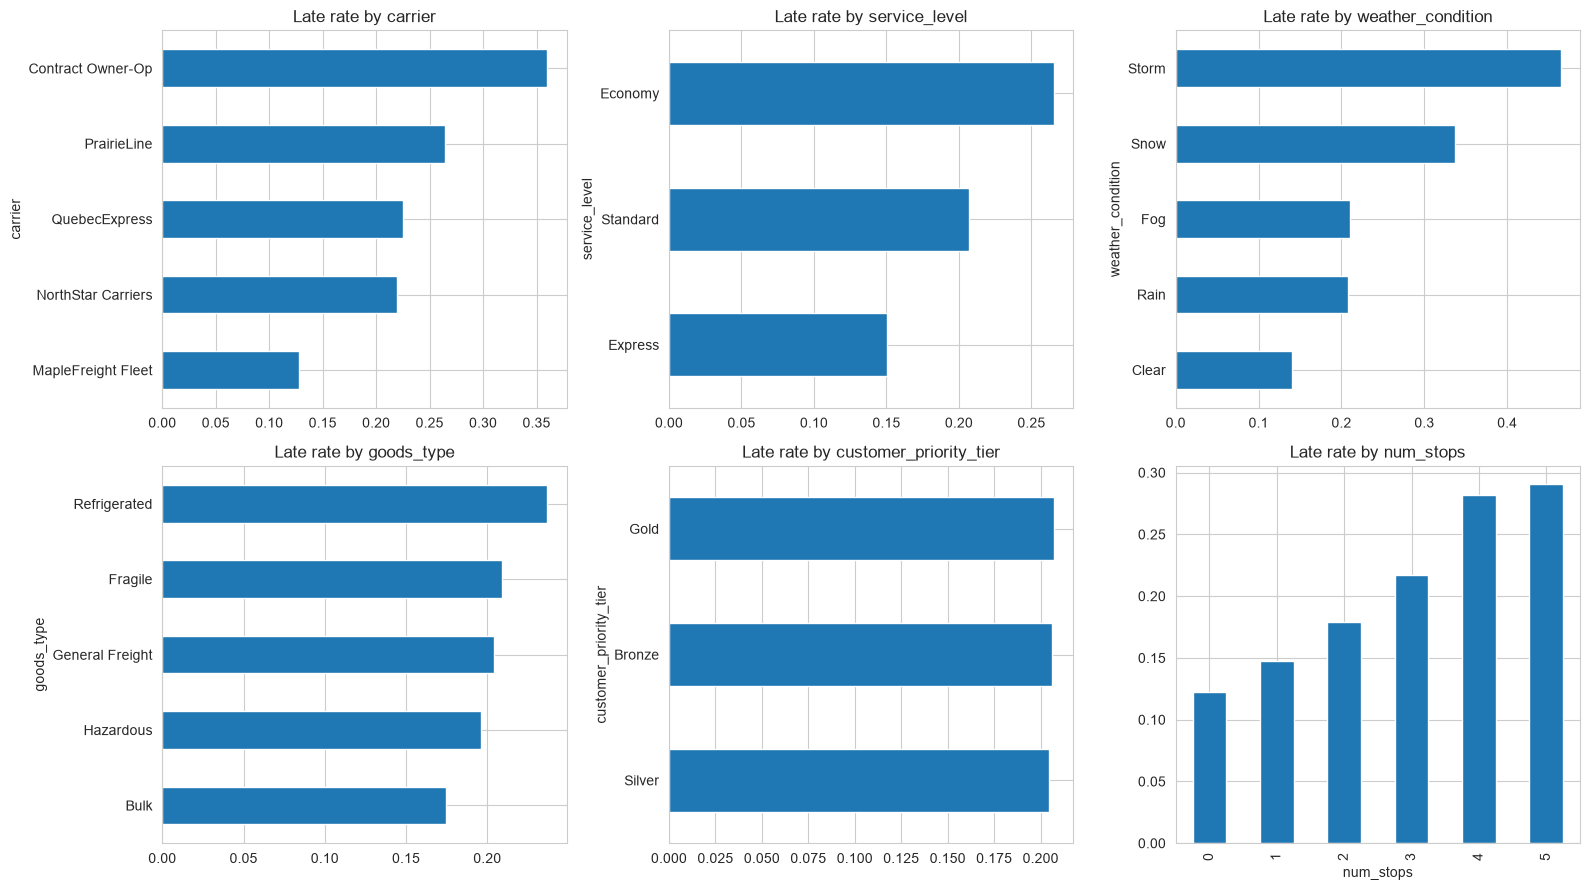

In [22]:
# Late rate for each category column
cats = ["carrier", "service_level", "weather_condition", "goods_type", "customer_priority_tier"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, cats):
# Plot late rate by category
    df.groupby(c)["delivered_late"].mean().sort_values().plot(kind="barh", ax=ax, title=f"Late rate by {c}")
    # Add counts on each bar
    # counts = df[c].value_counts()
df.groupby("num_stops")["delivered_late"].mean().plot(kind="bar", ax=axes.flat[5], title="Late rate by num_stops")
plt.tight_layout()
plt.show()

## numeric and correlation

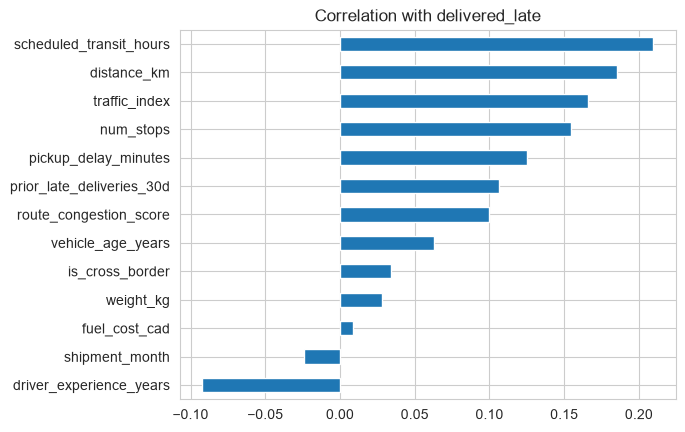

In [23]:
# Correlation of numeric features with the target
corr = df.select_dtypes("number").corr()["delivered_late"].drop("delivered_late").sort_values()
corr.plot(kind="barh", title="Correlation with delivered_late")
plt.show()

## Late rate because of late pickup or delay

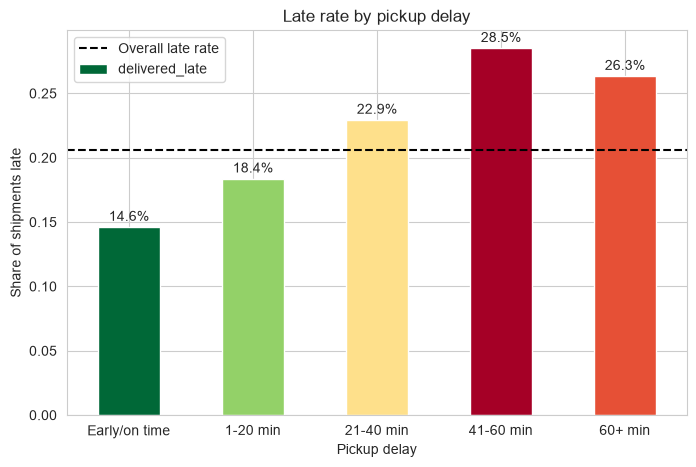

In [30]:
# Late rate by pickup delay
bins = [-25, 0, 20, 40, 60, 150]
labels = ["Early/on time", "1-20 min", "21-40 min", "41-60 min", "60+ min"]
df["pickup_group"] = pd.cut(df["pickup_delay_minutes"], bins, labels=labels)

rate = df.groupby("pickup_group", observed=True)["delivered_late"].mean()
colors = plt.cm.RdYlGn_r((rate - rate.min()) / (rate.max() - rate.min()))

# late rate by pickup delay bar chart with overall late rate line
ax = rate.plot(kind="bar", color=colors, figsize=(8, 5))
ax.axhline(df["delivered_late"].mean(), color="black", linestyle="--", label="Overall late rate")
ax.set_title("Late rate by pickup delay")
ax.set_xlabel("Pickup delay")
ax.set_ylabel("Share of shipments late")
ax.set_xticklabels(labels, rotation=0)
# Add counts and % on each bar
for i, v in enumerate(rate): # e
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")
ax.legend()
plt.show()

df = df.drop(columns="pickup_group")  # helper column, not needed later

**Findings**
- Class imbalance: about 20.6% of shipments are late. (close to 21% as mentioned in the question)
- Weather is a strong driver: late rate is 14% in clear weather, 34% in snow and 47% in storms.
- Carrier matters: Contract Owner-Op is late 36% of the time vs 13% for MapleFreight Fleet.
- Service level: Economy 27% late vs Express 15%.
- More stops means more delays: 12% with no stops, 29% with five.
- Customer tier, origin and destination city show almost no difference (all about 19-23%), so they are weak predictors.
- Top numeric correlations: scheduled_transit_hours (0.21), distance_km (0.19), traffic_index (0.17), num_stops (0.16), pickup_delay_minutes (0.13). Experienced drivers are slightly less late (-0.09).

# **Feature enginerring and Data preparation**

Creating new features from information available at dispatch, then splitting into train and test sets. Missing values are filled inside the model pipeline, using training data only.

## new features

In [33]:
# New features (all known before delivery)
df["required_speed_kmh"] = df["distance_km"] / df["scheduled_transit_hours"]
df["stops_per_100km"] = df["num_stops"] / df["distance_km"] * 100
df["severe_weather"] = df["weather_condition"].isin(["Snow", "Storm"]).astype(int)
df["pickup_late_flag"] = (df["pickup_delay_minutes"] > 20).astype(int)

df[["required_speed_kmh", "stops_per_100km", "severe_weather", "pickup_late_flag", "delivered_late"]].corr()["delivered_late"].round(3)

required_speed_kmh   -0.043
stops_per_100km       0.019
severe_weather        0.195
pickup_late_flag      0.115
delivered_late        1.000
Name: delivered_late, dtype: float64

## features, target and split

In [34]:
from sklearn.model_selection import train_test_split

# shipment_id is just a label, so it is not a feature
X = df.drop(columns=["shipment_id", "delivered_late"])
y = df["delivered_late"]

# stratify keeps the 21% late share equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Late share - train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (4800, 24) | Test: (1200, 24)
Late share - train: 0.206 | test: 0.206


The 24 counts the original columns minus shipment_id and the target, plus the 4 new ones.

**Findings**
- Added severe_weather (correlation 0.20 with late) and pickup_late_flag (0.12); both are useful.
- `required_speed_kmh` (-0.04) and stops_per_100km (0.02) are weak on their own, but they are kept and the models will show whether they help.
- Data split 80/20 with stratification: 4,800 train and 1,200 test rows, each about 20.6% late.
- The test set is kept untouched until final evaluation.

# **6. Data Preprocessing**
Filling missing values, scaling numeric features and encoding categories. Fitted on the training set only to avoid leakage.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = X_train.select_dtypes("object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Numbers: fill gaps with median, then scale. Categories: fill gaps with "Unknown", then one-hot encode
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

# Fit on train only, then apply to both
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

print("Categorical:", cat_cols)
print("Numeric columns:", len(num_cols))
print("Processed shapes:", X_train_p.shape, X_test_p.shape)

Categorical: ['origin_city', 'destination_city', 'carrier', 'service_level', 'goods_type', 'customer_priority_tier', 'weather_condition']
Numeric columns: 17
Processed shapes: (4800, 56) (1200, 56)


**Findings**
- Numeric gaps filled with the median; missing weather set to "Unknown".
- Numeric features scaled; 7 categorical columns one-hot encoded.
- The data became 56 numeric columns with no missing values: 4,800 train rows and 1,200 test rows.
- Everything was fitted on training data only, so the test set stays unseen.

# **7. Baseline Models**
A "predict on time" dummy and a logistic regression with class weights. Every later model is compared against these.